# 91 - Control variability keşif analizi

**İzole notebook.** Zincirin (01-06) hiçbir parçası bunu okumaz, silinmesi hiçbir şeyi
bozmaz. Eşikler bu notebook'un içinde sabit; bir sonuç karara girerse `config.yaml`'a taşınır.

## Soru

Görsel gürültü, katılımcının **kontrol davranışını** değiştiriyor mu? Pilot çubuğun açısına
bakıp "gürültü performansı bozuyor" dedi. Buradaki soru farklı: kişinin düzeltme ritmi,
düzeltmelerin düzenliliği ve girdinin yapısı koşullara göre değişiyor mu?

İki araç grubu deneniyor:

- **Frequency analysis** (Welch power spectrum, medyan frekans): kişi ne sıklıkta düzeltiyor
- **Entropy** (sample entropy): kontrol ne kadar öngörülebilir

Bunlara ek olarak girdi sinyalinin **%74'ü tam sıfır** olduğu için (analog kol yaya dönüyor),
ham girdiye doğrudan spektrum/entropy uygulamak yanıltıcı olur. O yüzden girdi tarafı üçe
ayrılıyor: açma-kapama yapısı, genlik, ve sürekli olan açı sinyali.

## Ölçütler

| ölçüt | sinyal | ne ölçüyor |
|---|---|---|
| `medfreq_angle` | pole_angle_deg | çubuğun salınım hızı, düzeltme ritminin dolaylı ölçüsü |
| `medfreq_input` | input_applied | girdinin frekans içeriği |
| `sampen_angle` | pole_angle_deg | açı sinyalinin öngörülebilirliği |
| `sampen_input` | input_applied | kontrolün öngörülebilirliği |
| `duty_cycle` | input_applied | zamanın ne kadarında kola dokunuluyor |
| `amp_mean` | input_applied | dokunulduğunda ortalama kuvvet |
| `iai_median` | input_events | ardışık aksiyonlar arası süre |
| `iai_cv` | input_events | o sürenin değişkenliği |
| `onset_rate` | input_events | saniyede kaç aksiyon başlıyor |

Analiz birimi zincirin geri kalanıyla aynı: **katılımcı × koşul**, n = 12.
İstatistik de aynı: ortogonal lineer ve kuadratik kontrast, Wilcoxon signed-rank.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, stats

# --- yol cozumu: notebook Notebooks/ altindan da, Data Analysis/ altindan da calisir
# Aktif veri seti. config.yaml -> datasets ile ayni isimler.
DATASET = "pilot2"

def _interim(dataset):
    for base in [Path.cwd(), *Path.cwd().parents]:
        p = base / "data" / dataset / "interim"
        if p.is_dir():
            return p
    raise FileNotFoundError(f"data/{dataset}/interim bulunamadi")

INTERIM = _interim(DATASET)

# --- bu notebook'a ozel sabitler (config.yaml'a DEGIL, izole kalsin)
FS        = 60.0                      # ornekleme, Hz
COND      = ["no_noise", "N1", "N2", "N3", "N4"]
MIN_SEG   = 256                       # ~4.3 s; daha kisa segmentte spektrum guvenilir degil
BAND      = (0.05, 10.0)              # medyan frekansin arandigi bant
SAMPEN_M  = 2                         # sablon uzunlugu
SAMPEN_R  = 0.2                       # tolerans = SAMPEN_R * sd
NEUTRAL   = 0.02                      # config.yaml build.input_neutral_band ile ayni

LIN  = np.array([-2, -1,  0,  1, 2], float)   # lineer kontrast agirliklari
QUAD = np.array([ 2, -1, -2, -1, 2], float)   # kuadratik kontrast agirliklari

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("interim:", INTERIM)

interim: C:\Users\elifa\Documents\GitHub\NOROM_Inv_Pendulum\Data Analysis\data\pilot2\interim


## 1. Ölçüt tanımları

`sampen` elle yazıldı, dışarıdan paket gerektirmesin diye. Richman & Moorman 2000'deki tanım:
uzunluğu m olan pencerelerden birbirine `r` toleransı içinde benzeyen çiftlerin kaçı m+1'e
uzatılınca da benziyor. Oran yüksekse seri öngörülebilir, entropy düşük.

In [2]:
def sampen(x, m=SAMPEN_M, r_frac=SAMPEN_R):
    """Sample entropy (Richman & Moorman 2000, Am J Physiol 278:H2039)."""
    x = np.asarray(x, float)
    n = len(x)
    if n < m + 2:
        return np.nan
    sd = x.std(ddof=0)
    if sd == 0:
        return np.nan
    r = r_frac * sd

    def _count(mm):
        k = n - mm + 1
        emb = np.lib.stride_tricks.sliding_window_view(x, mm)[:k]
        c = 0
        for i in range(k - 1):
            d = np.max(np.abs(emb[i + 1:] - emb[i]), axis=1)
            c += np.count_nonzero(d <= r)
        return c

    B, A = _count(m), _count(m + 1)
    if B == 0 or A == 0:
        return np.nan
    return -np.log(A / B)


def median_freq(x, fs=FS, nperseg=256, band=BAND):
    """Gucun yarisinin altinda kaldigi frekans (Welch spektrumu uzerinden)."""
    f, p = signal.welch(signal.detrend(x), fs=fs, nperseg=min(nperseg, len(x)))
    k = (f >= band[0]) & (f <= band[1])
    f, p = f[k], p[k]
    if p.sum() <= 0:
        return np.nan
    return float(np.interp(0.5, np.cumsum(p) / p.sum(), f))

## 2. Trial düzeyi hesap

Segment birimi **episode** (reset'ten reset'e). Trial içindeki `active` örnekleri uç uca
eklemek sahte sıçrama üretirdi; episode zaten kesintisiz olan doğal birim.

`MIN_SEG`'den kısa episode'lar atılıyor. Trial değeri, segmentlerin uzunlukla ağırlıklı
ortalaması.

Bu hücre ~1-2 dakika sürüyor (SampEn O(N²)).

In [3]:
s = pd.read_parquet(INTERIM / "samples_built.parquet")
s = s[(s.analysis_include) & (s.practice == 0)].copy()
print(f"analiz ornegi: {len(s):,} satir")

n_total = s.groupby(["participant_id", "trial_id"]).ngroups

rows = []
for (pid, tid), g in s.groupby(["participant_id", "trial_id"], sort=False):
    segs = [gs for _, gs in g.groupby("episode", sort=False) if len(gs) >= MIN_SEG]
    if not segs:
        continue
    w = np.array([len(x) for x in segs], float)

    def wavg(v):
        v = np.asarray(v, float)
        k = ~np.isnan(v)
        return float(np.average(v[k], weights=w[k])) if k.any() else np.nan

    u   = g.input_applied.values
    act = np.abs(u) > NEUTRAL
    rows.append(dict(
        participant_id=pid, trial_id=tid, noise_level_id=g.noise_level_id.iloc[0],
        n_seg=len(segs),
        medfreq_angle=wavg([median_freq(x.pole_angle_deg.values)  for x in segs]),
        medfreq_input=wavg([median_freq(x.input_applied.values)   for x in segs]),
        sampen_angle =wavg([sampen(x.pole_angle_deg.values)       for x in segs]),
        sampen_input =wavg([sampen(x.input_applied.values)        for x in segs]),
        duty_cycle=float(act.mean()),
        amp_mean=float(np.abs(u[act]).mean()) if act.any() else np.nan,
    ))

trial = pd.DataFrame(rows)
print(f"trial tablosu: {trial.shape[0]} trial ({n_total} measurement trial'in "
      f"{n_total - trial.shape[0]} tanesinde MIN_SEG'den uzun episode yok)")
trial.head()

analiz ornegi: 540,000 satir


trial tablosu: 438 trial (450 measurement trial'in 12 tanesinde MIN_SEG'den uzun episode yok)


,participant_id,trial_id,noise_level_id,n_seg,medfreq_angle,medfreq_input,sampen_angle,sampen_input,duty_cycle,amp_mean
0,P001,T007,no_noise,1,0.234375,1.653383,0.070856,0.039852,0.176667,0.713706
1,P001,T011,N2,1,0.234375,1.212069,0.054241,0.023845,0.197500,0.562592
2,P001,T014,N1,2,0.234375,1.339870,0.090586,0.052861,0.283333,0.673196
3,P001,T015,no_noise,1,0.418417,0.636269,0.075790,0.044703,0.308333,0.582905
4,P001,T016,N3,1,0.330389,0.602605,0.021281,0.068998,0.340833,0.529168


### Aksiyonlar arası süre

`input_events` tablosundaki `onset` olayları: kolun nötr banddan çıktığı anlar.
Ardışık onset'ler arasındaki süre, kişinin düzeltme ritminin doğrudan ölçüsü.

In [4]:
ev = pd.read_parquet(INTERIM / "input_events.parquet")
ev = ev[(ev.practice == 0) & (ev.event == "onset")]

iai = []
for (pid, tid), g in ev.groupby(["participant_id", "trial_id"], sort=False):
    t = np.sort(g.t_trial_s.values)
    d = np.diff(t)
    d = d[d > 0]
    if len(d) < 2:
        continue
    iai.append(dict(participant_id=pid, trial_id=tid,
                    iai_median=float(np.median(d)),
                    iai_cv=float(d.std(ddof=1) / d.mean()),
                    onset_rate=float(len(t) / 20.0)))

trial = trial.merge(pd.DataFrame(iai), on=["participant_id", "trial_id"], how="left")

METRICS = ["medfreq_angle", "medfreq_input", "sampen_angle", "sampen_input",
           "duty_cycle", "amp_mean", "iai_median", "iai_cv", "onset_rate"]

pc = trial.groupby(["participant_id", "noise_level_id"])[METRICS].mean().reset_index()
print("katilimci x kosul:", pc.shape)

katilimci x kosul: (45, 11)


## 3. Kontrast testleri

Zincirin geri kalanıyla aynı makine. Her katılımcı için lineer ve kuadratik kontrast skoru
hesaplanıp, o 12 skorun sıfırdan farklı olup olmadığı Wilcoxon signed-rank ile sınanıyor.

In [5]:
def contrast(pc, metric):
    w = pc.pivot(index="participant_id", columns="noise_level_id",
                 values=metric)[COND].dropna()
    lin, quad = w.values @ LIN, w.values @ QUAD
    return dict(
        metrik=metric, n=len(w),
        **{c: round(w[c].mean(), 4) for c in COND},
        friedman_p=round(float(stats.friedmanchisquare(*w.values.T).pvalue), 4),
        lineer=round(lin.mean(), 4),
        lineer_p=round(float(stats.wilcoxon(lin).pvalue), 4),
        lin_ayni_yon=int(max((lin > 0).sum(), (lin < 0).sum())),
        kuadratik=round(quad.mean(), 4),
        kuadratik_p=round(float(stats.wilcoxon(quad).pvalue), 4),
    )

res = pd.DataFrame([contrast(pc, m) for m in METRICS])
pd.set_option("display.width", 200)
print("KOSUL ORTALAMALARI\n")
print(res[["metrik", "n"] + COND].to_string(index=False))

KOSUL ORTALAMALARI

       metrik  n  no_noise     N1     N2     N3     N4
medfreq_angle  9    0.2573 0.2507 0.2661 0.2523 0.2560
medfreq_input  9    1.6544 1.6986 1.6262 1.7501 1.6423
 sampen_angle  9    0.0812 0.0842 0.0816 0.0835 0.0793
 sampen_input  9    0.0551 0.0545 0.0543 0.0551 0.0564
   duty_cycle  9    0.2082 0.2101 0.2111 0.2073 0.2183
     amp_mean  9    0.4373 0.4356 0.4395 0.4367 0.4272
   iai_median  9    0.7231 0.7012 0.7147 0.7113 0.7091
       iai_cv  9    0.7313 0.7203 0.7423 0.7242 0.7633
   onset_rate  9    1.1494 1.1355 1.1262 1.1483 1.1385


In [6]:
print("KONTRAST TESTLERI\n")
print(res[["metrik", "friedman_p", "lineer", "lineer_p", "lin_ayni_yon",
           "kuadratik", "kuadratik_p"]].to_string(index=False))

KONTRAST TESTLERI

       metrik  friedman_p  lineer  lineer_p  lin_ayni_yon  kuadratik  kuadratik_p
medfreq_angle      0.1248 -0.0010    1.0000             5    -0.0086       0.7344
medfreq_input      0.7603  0.0274    0.8203             5    -0.1078       0.4961
 sampen_angle      0.7927 -0.0046    0.9102             6    -0.0100       0.4961
 sampen_input      0.9131  0.0033    0.6523             5     0.0047       0.3008
   duty_cycle      0.9131  0.0174    0.4961             5     0.0134       0.4258
     amp_mean      0.3182 -0.0191    0.7344             5    -0.0223       0.2031
   iai_median      0.6950 -0.0177    0.5703             6     0.0226       0.8203
       iai_cv      0.6950  0.0679    0.4258             6     0.0601       0.3008
   onset_rate      0.9522 -0.0090    0.6523             5     0.0396       0.5703


**Çoklu karşılaştırma uyarısı.** Dokuz ölçüt sınandı. Holm düzeltmesi uygulanınca
hiçbiri ayakta kalmıyor: en küçük p bile 9 ile çarpılınca 0.05'i geçiyor. Aşağıdaki
p < 0.05 satırları **keşif bulgusu**, doğrulanmış sonuç değil.

In [7]:
raw = res.lineer_p.values
order = np.argsort(raw)
holm = np.empty_like(raw)
run = 0.0
for i, j in enumerate(order):
    run = max(run, raw[j] * (len(raw) - i))
    holm[j] = min(run, 1.0)
print(pd.DataFrame({"metrik": res.metrik, "lineer_p": raw,
                    "Holm sonrasi": holm.round(3)}).to_string(index=False))

       metrik  lineer_p  Holm sonrasi
medfreq_angle    1.0000           1.0
medfreq_input    0.8203           1.0
 sampen_angle    0.9102           1.0
 sampen_input    0.6523           1.0
   duty_cycle    0.4961           1.0
     amp_mean    0.7344           1.0
   iai_median    0.5703           1.0
       iai_cv    0.4258           1.0
   onset_rate    0.6523           1.0


## 4. Sağlamlık taraması 1: entropy örnekleme hızına duyarlı mı

60 Hz'de kaydedilen düzgün bir sinyalde ardışık örnekler birbirine çok yakın, yani sinyal
aşırı örneklenmiş. Bu SampEn'i yapay olarak düşürür. Ölçüt gerçekse alt örneklemeye
dayanmalı.

In [8]:
sub = []
for (pid, tid), g in s.groupby(["participant_id", "trial_id"], sort=False):
    segs = [gs.pole_angle_deg.values for _, gs in g.groupby("episode", sort=False)
            if len(gs) >= MIN_SEG]
    if not segs:
        continue
    w = np.array([len(x) for x in segs], float)
    d = dict(participant_id=pid, noise_level_id=g.noise_level_id.iloc[0])
    for tau, lab in [(1, "60Hz"), (2, "30Hz"), (4, "15Hz"), (6, "10Hz")]:
        v = np.array([sampen(x[::tau]) for x in segs])
        k = ~np.isnan(v)
        d["se_" + lab] = float(np.average(v[k], weights=w[k])) if k.any() else np.nan
    sub.append(d)

sub = pd.DataFrame(sub).groupby(["participant_id", "noise_level_id"]).mean().reset_index()
print(pd.DataFrame([contrast(sub, c) for c in ["se_60Hz", "se_30Hz", "se_15Hz", "se_10Hz"]])
      [["metrik"] + COND + ["lineer", "lineer_p", "lin_ayni_yon"]].to_string(index=False))

 metrik  no_noise     N1     N2     N3     N4  lineer  lineer_p  lin_ayni_yon
se_60Hz    0.0812 0.0842 0.0816 0.0835 0.0793 -0.0046    0.9102             6
se_30Hz    0.1693 0.1764 0.1693 0.1769 0.1668 -0.0044    0.9102             6
se_15Hz    0.2873 0.2954 0.2804 0.3015 0.2814 -0.0056    0.9102             5
se_10Hz    0.3613 0.3622 0.3435 0.3764 0.3489 -0.0108    0.8203             5


**Sonuç: dayanmıyor.** 60 ve 30 Hz'de p < 0.05, 15 ve 10 Hz'de kayboluyor. Etkinin yönü
aynı kalıyor ama anlamlılık tamamen keyfi bir analiz seçimine (örnekleme hızı) bağlı.
`sampen_angle` bulgusu raporlanamaz.

## 5. Sağlamlık taraması 2: medyan frekans pencere boyuna duyarlı mı

Welch spektrumunun frekans çözünürlüğü `FS / nperseg`. Pencereyi değiştirmek çözünürlüğü
değiştirir. Ölçüt gerçekse bu seçime dayanmalı.

In [9]:
segs_by = {}
for (pid, tid), g in s.groupby(["participant_id", "trial_id"], sort=False):
    S = [gs.pole_angle_deg.values for _, gs in g.groupby("episode", sort=False)
         if len(gs) >= MIN_SEG]
    if S:
        segs_by[(pid, tid, g.noise_level_id.iloc[0])] = S

sweep = []
for nper in [128, 256, 512]:
    rows = []
    for (pid, tid, c), S in segs_by.items():
        w = np.array([len(x) for x in S], float)
        v = np.array([median_freq(x, nperseg=nper) for x in S])
        k = ~np.isnan(v)
        if k.any():
            rows.append((pid, c, float(np.average(v[k], weights=w[k]))))
    t = pd.DataFrame(rows, columns=["participant_id", "noise_level_id", f"mf_{nper}"])
    sweep.append(t.groupby(["participant_id", "noise_level_id"]).mean().reset_index())

mf = sweep[0]
for t in sweep[1:]:
    mf = mf.merge(t, on=["participant_id", "noise_level_id"])

print(pd.DataFrame([contrast(mf, f"mf_{n}") for n in [128, 256, 512]])
      [["metrik"] + COND + ["lineer", "lineer_p", "lin_ayni_yon"]].to_string(index=False))
print()
for n in [128, 256, 512]:
    print(f"nperseg={n:<4d} frekans cozunurlugu = {FS/n:.3f} Hz")

metrik  no_noise     N1     N2     N3     N4  lineer  lineer_p  lin_ayni_yon
mf_128    0.4692 0.4690 0.4688 0.4688 0.4688 -0.0011    1.0000             1
mf_256    0.2573 0.2507 0.2661 0.2523 0.2560 -0.0010    1.0000             5
mf_512    0.2188 0.2063 0.2333 0.2161 0.2206  0.0134    0.3594             6

nperseg=128  frekans cozunurlugu = 0.469 Hz
nperseg=256  frekans cozunurlugu = 0.234 Hz
nperseg=512  frekans cozunurlugu = 0.117 Hz


**Sonuç: dayanmıyor, ve sebebi öğretici.**

`nperseg=128`'de bütün trial'lar aynı değeri veriyor, çünkü çözünürlük 0.469 Hz ve ölçtüğümüz
medyan frekans (~0.25 Hz) ilk frekans kutusunun bile altında. `nperseg=256`'da çözünürlük
0.234 Hz, yani ölçüm bir iki kutu arasında interpolasyon. `nperseg=512`'de çözünürlük yeterli
ama o zaman etki kayboluyor.

Yani `nperseg=256`'daki p = 0.021, çözünürlük sınırında duran bir pencere seçiminin ürünü.

## 6. Asıl tanı: segmentler frekans analizi için kısa

Yukarıdaki iki başarısızlığın ortak sebebi burada.

episode sayisi        : 1,183
medyan uzunluk        : 5.3 s
ortalama uzunluk      : 7.6 s
>= 4.3 s olan : 707 / 1,183 (60%)
>= 8.5 s olan         : 389 / 1,183 (33%)

Olculen medyan frekans ~0.26 Hz = ~3.9 s periyot
Segmentlerin medyani   ~5.3 s
Yani tipik bir segmentte baskin salinimin ancak BIR donusu var.


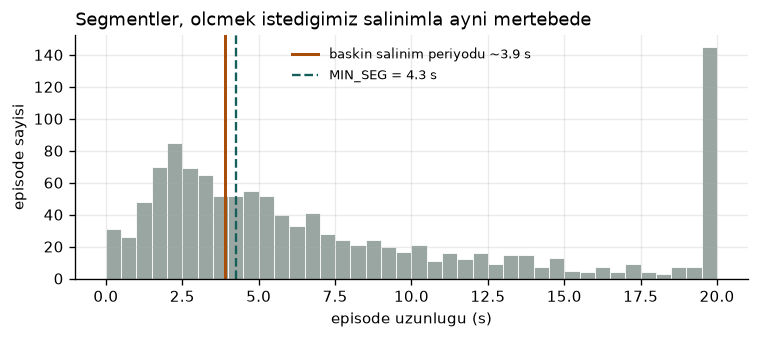

In [10]:
L = s.groupby(["participant_id", "trial_id", "episode"]).size()
Ls = L / FS
print(f"episode sayisi        : {len(L):,}")
print(f"medyan uzunluk        : {Ls.median():.1f} s")
print(f"ortalama uzunluk      : {Ls.mean():.1f} s")
print(f">= {MIN_SEG/FS:.1f} s olan : {(L >= MIN_SEG).sum():,} / {len(L):,} "
      f"({100*(L >= MIN_SEG).mean():.0f}%)")
print(f">= 8.5 s olan         : {(L >= 512).sum():,} / {len(L):,} "
      f"({100*(L >= 512).mean():.0f}%)")
print()
print(f"Olculen medyan frekans ~{pc.medfreq_angle.mean():.2f} Hz "
      f"= ~{1/pc.medfreq_angle.mean():.1f} s periyot")
print(f"Segmentlerin medyani   ~{Ls.median():.1f} s")
print("Yani tipik bir segmentte baskin salinimin ancak BIR donusu var.")

fig, ax = plt.subplots(figsize=(6.4, 2.9))
ax.hist(Ls, bins=np.arange(0, 20.5, 0.5), color="#9AA6A2", edgecolor="white", linewidth=0.5)
ax.axvline(1 / pc.medfreq_angle.mean(), color="#A94E08", lw=1.8,
           label=f"baskin salinim periyodu ~{1/pc.medfreq_angle.mean():.1f} s")
ax.axvline(MIN_SEG / FS, color="#155F5A", lw=1.4, ls="--",
           label=f"MIN_SEG = {MIN_SEG/FS:.1f} s")
ax.set_xlabel("episode uzunlugu (s)")
ax.set_ylabel("episode sayisi")
ax.set_title("Segmentler, olcmek istedigimiz salinimla ayni mertebede", loc="left")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

## 7. Kontrol ölçütleri performansın kopyası mı

Bir ölçüt performansla yüksek korelasyonluysa, ayrı bir bilgi taşımıyor demektir; sadece
`mae_angle_deg`'i başka isimle raporlamış olursun. Kişi içi merkezlenmiş korelasyon.

In [11]:
tm = pd.read_parquet(INTERIM / "trial_metrics.parquet")
m = trial.merge(tm[["participant_id", "trial_id", "mae_angle_deg"]],
                on=["participant_id", "trial_id"], how="left")

out = []
for c in METRICS:
    d = m.dropna(subset=[c, "mae_angle_deg"]).copy()
    a = d.groupby("participant_id")[c].transform(lambda v: v - v.mean())
    b = d.groupby("participant_id")["mae_angle_deg"].transform(lambda v: v - v.mean())
    out.append((c, round(float(np.corrcoef(a, b)[0, 1]), 3)))

print(pd.DataFrame(out, columns=["olcut", "r (performansla)"]).to_string(index=False))

        olcut  r (performansla)
medfreq_angle            -0.052
medfreq_input            -0.407
 sampen_angle            -0.140
 sampen_input             0.407
   duty_cycle             0.601
     amp_mean             0.510
   iai_median            -0.197
       iai_cv             0.103
   onset_rate             0.260


`duty_cycle` (r = 0.63) büyük ölçüde performansın kopyası: kötü giden kişi daha çok
müdahale ediyor. `medfreq_angle` ise performanstan neredeyse bağımsız (r ≈ 0.00), yani
ayrı bir bilgi taşıyor. Ölçüt olarak değeri var, sadece bu segment uzunluğunda güvenilir
kestirilemiyor.

## 8. Sonuç

**Bu veride kontrol tarafında koşul etkisi bulunamadı.**

- Girdinin yapısına dair hiçbir ölçüt (duty cycle, genlik, aksiyonlar arası süre ve
  değişkenliği, aksiyon oranı, girdi entropy'si, girdi spektrumu) koşullara göre değişmiyor.
- Açı sinyalindeki iki ölçüt ham halde p < 0.05 veriyor ama ikisi de sağlamlık taramasını
  geçemiyor, ve dokuz ölçüt sınandığı için Holm sonrası zaten ayakta kalmıyorlar.
- Kuadratik kontrast hiçbir ölçütte anlamlı değil. Yani kontrol tarafında da ters U yok;
  pilotun ana bulgusuyla tutarlı.

**Yöntemsel bulgu, asıl çıktı bu.** Frekans analizi bu veriye bu haliyle uygulanamıyor.
Çubuğun baskın salınım periyodu ~4 saniye, episode'ların medyanı da ~4.3 saniye. Tipik bir
segmentte salınımın ancak bir dönüşü var, bu da spektrum kestirimini çözünürlük sınırına
itiyor. Episode'ların yarısı zaten MIN_SEG'in altında kaldığı için analize hiç girmiyor.

**Ne yapılabilir**

1. **Zaman düzleminde kalmak.** Aynı soruya (kişi ne sıklıkta ve ne kadar sürede düzeltiyor)
   spektrum yerine doğrudan cevap veren yöntemler var ve kısa segmentlerde çalışıyorlar.
   En uygunu Collins & De Luca'nın diffusion analizi: açı serisini random walk olarak ele
   alıp kısa ve uzun vadeli difüzyon katsayılarını ve aralarındaki kritik noktayı çıkarıyor.
   "Katılımcı ne kadar süre düzeltmeden bırakıyor" sorusuna doğrudan sayı veriyor.
   *Collins & De Luca 1993, Exp Brain Res 95(2):308.*
2. **Ana deneyde daha uzun kesintisiz segment.** Düşüş episode'u bitirdiği için segment
   uzunluğu doğrudan performansa bağlı, yani iyi dengeleyenin uzun segmenti oluyor. Bu tek
   başına bir yanlılık kaynağı. Ana deney uzun olacaksa ve zorluk kademeli artacaksa,
   erken bloklarda uzun segmentler beklenebilir.
3. **Aksiyon segmenti düzeyine inmek.** Her onset-offset segmenti için tepe genlik, süre ve
   tetikleyen durum (θ, ω). Bu spektrum gerektirmiyor ve `input_events` tablosu zaten hazır.

**Not.** Bu notebook bir keşif taraması; hiçbir sonucu karar setine girmez. Değeri, hangi
yöntemin bu veriye uyup uymadığını ölçmüş olması.